# Machine Learning Models

## Baseline Linear Regression

Objective

Train a baseline regression model for Remaining Useful Life prediction.

## Load libraries and dataset

Load the prepared dataset

In [4]:
import pandas as pd
df = pd.read_csv('../data/processed/train_FD001_features.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 91 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   unit_number                        20631 non-null  int64  
 1   time_in_cycles                     20631 non-null  int64  
 2   operational_setting_1              20631 non-null  float64
 3   operational_setting_2              20631 non-null  float64
 4   operational_setting_3              20631 non-null  float64
 5   sensor_measurement_1               20631 non-null  float64
 6   sensor_measurement_2               20631 non-null  float64
 7   sensor_measurement_3               20631 non-null  float64
 8   sensor_measurement_4               20631 non-null  float64
 9   sensor_measurement_5               20631 non-null  float64
 10  sensor_measurement_6               20631 non-null  float64
 11  sensor_measurement_7               20631 non-null  float64
 12  s

# Recreate X and y

The target is RUL, everything else other than identifiers like `unit_number` becomes our features.

## Split the data

In [5]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# 0. Drop warm up rows and leaky columns
df_model = df[df['time_in_cycles'] >= 5].reset_index(drop=True)

groups = df_model['unit_number']
x = df_model.drop(columns=['RUL', 'max_cycles', 'unit_number'])
y = df_model['RUL']

# 1. Split by engine; 80 engines train, 20 engines test
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(x, y, groups=groups))

x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# 2. Scale fit on train only
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(x_train.shape, x_test.shape)
print("train engines:", groups.iloc[train_idx].nunique(),
      "test engines:", groups.iloc[test_idx].nunique())
print("overlap:", set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))


(16241, 88) (3990, 88)
train engines: 80 test engines: 20
overlap: set()


## Import linear regression

Initialize and fit the model

In [8]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](88,)","[ -0.35,-137.94,3797.63,..., 0. , -5.11, -8.88]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](88,)","['time_in_cycles','operational_setting_1','operational_setting_2',..., 'sensor_measurement_19_change','sensor_measurement_20_change', 'sensor_measurement_21_change']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.084e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,88
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(63)


## Predict values for unseen test data

In [9]:
y_pred = model.predict(x_test)

## Evaluate model

Using three metrics:
- Mean absolute error
- Root mean squared error
- R² Score

In [13]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f} cycles")
print(f"RMSE: {rmse:.2f} cycles")
print(f"R²:   {r2:.3f}")

MAE:  24.90 cycles
RMSE: 31.39 cycles
R²:   0.764


# Plot predictions

Compare the predicted values to the actual values using scatter plots.

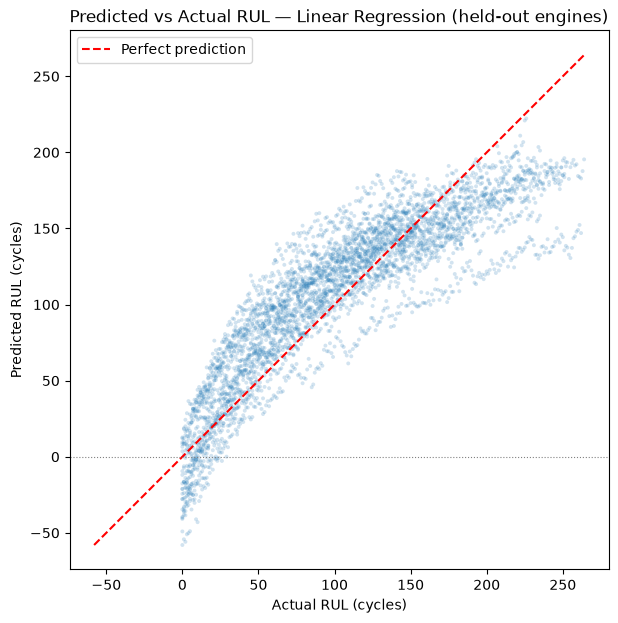

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_test, y_pred, alpha=0.2, s=8, edgecolor='none')

# Perfect prediction reference line
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')

ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')

ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Predicted RUL (cycles)')
ax.set_title('Predicted vs Actual RUL — Linear Regression (held-out engines)')
ax.set_aspect('equal')
ax.legend()


# Observations

- Points below the red line = the model predicts less life than the engine actually had.
- Points above the line = the model predicts more life than there was. These are the dangerous ones: the engine fails sooner than you were told.
- Predictions below zero. Linear regression is unbounded, so it will output negative RUL.
- A flattened, tilted cloud. The model will over predict at low actual RUL and under predict at high actual RUL.


# Residual plot

Residual = actual - predicted.

Text(0.5, 1.0, 'Residuals vs Actual RUL')

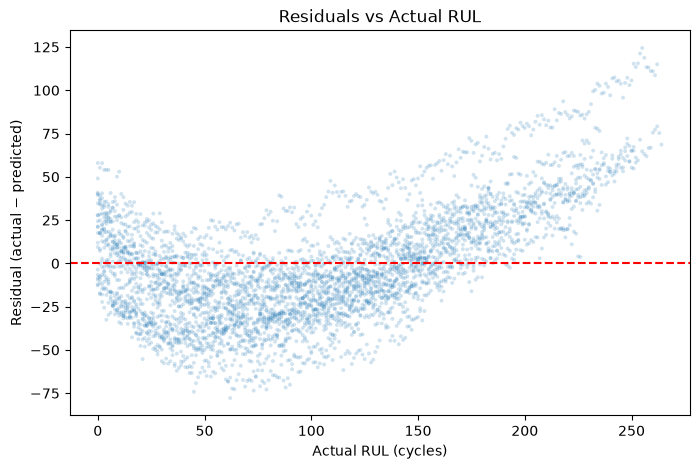

In [17]:
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test, residuals, alpha=0.2, s=8, edgecolor='none')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Residual (actual − predicted)')
ax.set_title('Residuals vs Actual RUL')